In [1]:
import numpy as np
from seaborn import kdeplot
import matplotlib.pyplot as plt
import os
from ot.lp import wasserstein_1d as wd

plt.style.use("ggplot")

In [2]:
budget = 4 ** 8
conditioning_list = [4 ** i for i in range(9)]

wds_nn = np.empty((10, len(conditioning_list)))
wds_ker = np.empty((10, len(conditioning_list)))
wds_sde = np.empty((10, len(conditioning_list)))
wds_mcmc = np.empty((10, len(conditioning_list)))
wds_nn_std = np.empty((10, len(conditioning_list)))
wds_ker_std = np.empty((10, len(conditioning_list)))
wds_sde_std = np.empty((10, len(conditioning_list)))
wds_mcmc_std = np.empty((10, len(conditioning_list)))
for i in range(10):
    output_root = "budget_results"
    output_dir = os.path.join(output_root, f"ode_{i}")
    wd_nn_array = np.load(os.path.join(output_dir, "wd_nn_array_mean.npy"))
    # wd_ker_array = np.load(os.path.join(output_dir, "wd_ker_array_mean.npy"))
    wd_sde_array = np.load(os.path.join(output_dir, "wd_nn_sde_array_mean.npy"))
    wd_mcmc_array = np.load(os.path.join(output_root, f"wd_mcmc_array_mean_{i}.npy"))
    wd_nn_std = np.load(os.path.join(output_dir, "wd_nn_array_std.npy"))
    # wd_ker_std = np.load(os.path.join(output_dir, "wd_ker_array_std.npy"))
    wd_sde_std = np.load(os.path.join(output_dir, "wd_nn_sde_array_std.npy"))
    wd_mcmc_std = np.load(os.path.join(output_root, f"wd_mcmc_array_std_{i}.npy"))

    wds_nn[i-1, :] = wd_nn_array
    # wds_ker[i-1, :] = wd_ker_array
    wds_sde[i-1, :] = wd_sde_array
    wds_mcmc[i-1, :] = wd_mcmc_array
    wds_nn_std[i-1, :] = wd_nn_std
    # wds_ker_std[i-1, :] = wd_ker_std
    wds_sde_std[i-1, :] = wd_sde_std
    wds_mcmc_std[i-1, :] = wd_mcmc_std

In [3]:
wd_means = np.mean(wds_nn, axis=0)
wd_stds = np.mean(wds_nn_std, axis=0)

wd_sde_means = np.mean(wds_sde, axis=0)
wd_sde_stds = np.mean(wds_sde_std, axis=0)

wd_ker_means = np.mean(wds_ker, axis=0)
wd_sde_stds = np.mean(wds_ker_std, axis=0)

In [4]:
wd_mcmc_means = np.mean(wds_mcmc, axis=0)
wd_mcmc_stds = np.mean(wds_nn_std, axis=0)

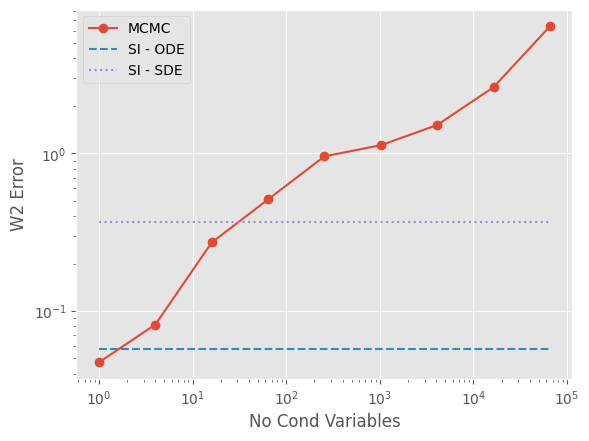

In [12]:
plt.plot(conditioning_list, wd_mcmc_means, label="MCMC", marker="o")
# plt.fill_between(conditioning_list, wd_mcmc_means - wd_mcmc_stds, wd_mcmc_means + wd_mcmc_stds, alpha=0.3)
plt.plot(conditioning_list, np.mean(wd_means) * np.ones(9), label="SI - ODE", linestyle="dashed")
plt.plot(conditioning_list, np.mean(wd_sde_means[:3]) * np.ones(9), label="SI - SDE", linestyle="dotted")
# plt.plot(conditioning_list, np.mean(wd_ker_means) * np.ones(9), label="SI - Ker", linestyle="dashdot")
# plt.axhline(np.mean(wd_nn_array).item(), label="SI")
plt.legend()
plt.yscale("log")
plt.xscale("log")
plt.xlabel("No Cond Variables")
plt.ylabel("W2 Error")
plt.savefig("images/budget_8G.pdf")

In [18]:
nn_samps

array([[ 0.30268887,  0.30239668,  0.3028274 , ...,  0.30269235,
         0.3026039 ,  0.30272788],
       [-2.2764192 , -1.9255389 ,  0.20371702, ...,  0.93785226,
         1.579623  ,  0.75568134],
       [ 1.3349171 ,  1.3327246 ,  1.3344545 , ...,  1.3350968 ,
         1.3347311 ,  1.3326015 ],
       ...,
       [ 4.226975  , -4.091593  , -4.402232  , ..., -3.7930734 ,
        -4.6962547 , -4.570904  ],
       [ 2.1324396 ,  2.132977  ,  2.1334183 , ...,  2.133976  ,
         2.1326141 ,  2.1317716 ],
       [ 0.46376944, -0.0613534 , -0.8388279 , ..., -0.8991793 ,
         1.253093  ,  1.6073663 ]], shape=(131072, 5000), dtype=float32)

<Axes: ylabel='Density'>

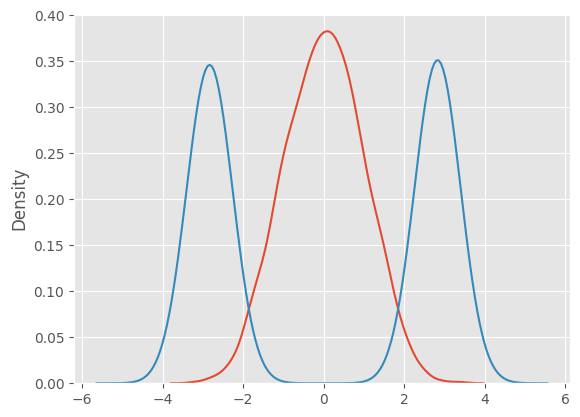

In [19]:
nn_samps = (np.load(f"nn_sde_results/ode_{0}/nn_samps.npy"))
rej_samps = np.load("rej_results/_0/rej_samps.npy")
cond_ys = np.load("rej_results/_0/conditioning_ys.npy")
kdeplot(nn_samps[1, :])
kdeplot(rej_samps[0, :])

In [6]:
nn_samps.T[:, 1::2]

array([[-2.3196094 , -0.8031901 , -1.2008958 , ...,  0.7327376 ,
         4.219262  ,  1.5540068 ],
       [-1.9666731 , -0.27429605,  0.6999517 , ..., -0.9693372 ,
        -4.110111  ,  0.19409873],
       [ 0.20216003, -0.72242856,  1.3782407 , ...,  1.3797315 ,
        -4.3665857 , -1.4586184 ],
       ...,
       [ 0.9284308 , -0.84729147, -1.4133675 , ...,  0.47190845,
        -3.7079728 , -1.646724  ],
       [ 1.5495414 , -0.7770629 , -0.39395106, ...,  1.2954367 ,
        -4.7245393 ,  3.7515223 ],
       [ 0.7506242 , -0.33681262, -1.7993442 , ...,  0.71680576,
        -4.568841  ,  4.470168  ]], shape=(5000, 65536), dtype=float32)

In [21]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "1"
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"

from tqdm.auto import tqdm
import numpy as np
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from jax import grad, vmap, random
import optax
import diffrax
import time
import json
import argparse

from triangular_transport.flows.sde_flow_trainer import (
    NNSDE,
)

from triangular_transport.flows.interpolants import (
    linear_interpolant_noise,
    linear_interpolant_der_noise,
)
from triangular_transport.flows.loss_functions import vec_field_loss, denoiser_loss
from triangular_transport.networks.flow_networks import MLP
from triangular_transport.flows.methods.sampling import inf_train_gen
from triangular_transport.flows.dataloaders import gaussian_reference_sampler

epochs = 400
cond_val = cond_ys[0]
solver_args = {"solver": diffrax.Dopri5(), "max_steps": 50000, "stepsize_controller": diffrax.PIDController(rtol=1e-4, atol=1e-6)}
train_dim = 4 ** 8
key = random.key(seed=0)
key, key1 = random.split(key=key, num=2)
batch_size = 2048
batch_size = min(batch_size, train_dim)
batch_size -= 1
steps_per_epoch = int(np.ceil(train_dim / batch_size))
steps = steps_per_epoch * epochs
print_every = 10000
yu_dimension = (1, 1)
target_data = inf_train_gen(data="8gaussians", rng=None, batch_size=train_dim)
dim = yu_dimension[0] + yu_dimension[1]
hidden_layer_list_vel = [256] * 3
hidden_layer_list_score = [512] * 4
velocity = MLP(
    key=key1,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list_vel,
    num_layers=len(hidden_layer_list_vel) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
score = MLP(
    key=key,
    dim=dim,
    time_varying=True,
    w=hidden_layer_list_score,
    num_layers=len(hidden_layer_list_score) + 1,
    activation_fn=jax.nn.gelu,  # GeLU worked well
)
v_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=1e-3,
    warmup_steps=400,
    decay_steps=steps,
    end_value=1e-5,
)
s_schedule = optax.warmup_cosine_decay_schedule(
    init_value=0.0,
    peak_value=3e-4,
    warmup_steps=400,
    decay_steps=steps,
    end_value=1e-5,
)
v_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adamw(v_schedule)
)
s_optimizer = optax.chain(
    optax.clip_by_global_norm(1.0), optax.adam(s_schedule)
)

interpolant = linear_interpolant_noise
interpolant_der = linear_interpolant_der_noise
interpolant_args = {"t": None, "x1": None, "x0": None, "z": None}
mean = 0.016955564
std = 2.029254
reference_sampler_args = {"mu": mean, "sigma": std}

trainer = NNSDE(
    target_density=None,
    velocity=velocity,
    score=score,
    v_optimizer=v_optimizer,
    s_optimizer=s_optimizer,
    interpolant=interpolant,
    interpolant_der=interpolant_der,
    reference_sampler=gaussian_reference_sampler,
    v_loss=vec_field_loss,
    s_loss=denoiser_loss,
    interpolant_args=interpolant_args,
    yu_dimension=yu_dimension,
    reference_sampler_args=reference_sampler_args,
)

start_train = time.perf_counter()
trainer.train(
    x1_data=target_data,
    train_dim=train_dim,
    batch_size=batch_size,
    steps=steps,
    x0_data=None,
    print_every=print_every,
);

Training neural network


  0%|          | 66/13200 [00:03<07:54, 27.70it/s]  

step = 0, train_v_loss = 0.0050855400040745735, train_eta_loss = 0.0006321255350485444, train_loss = 0.005717665539123118


 77%|███████▋  | 10103/13200 [00:18<00:04, 671.53it/s]

step = 10000, train_v_loss = -2.8740336894989014, train_eta_loss = -0.11140481382608414, train_loss = -2.9854385033249855


100%|██████████| 13200/13200 [00:22<00:00, 582.04it/s]

step = 13199, train_v_loss = -2.53855037689209, train_eta_loss = -0.12097398191690445, train_loss = -2.6595243588089943


In [22]:
cond_val

np.float64(0.30264372434941356)

In [24]:
def gamma_fn(t):
    return 0.1 * jnp.sqrt(2 * (t - t**2) + 1e-8)
solver_args = {"saveat": "t1", "eps": 5e-3}
cond_samples = trainer.conditional_sample(
    cond_values=cond_val,
    nsamples=10000,
    u0_cond=None,
    gamma=gamma_fn,
    solver_args=solver_args,
)

In [25]:
cond_samples

Array([[ 0.30263266,  3.2605808 ],
       [ 0.30240682,  3.4401772 ],
       [ 0.30269134, -2.6712434 ],
       ...,
       [ 0.3027896 , -2.56571   ],
       [ 0.3027356 ,  2.1043518 ],
       [ 0.30259338,  2.628034  ]], dtype=float32)

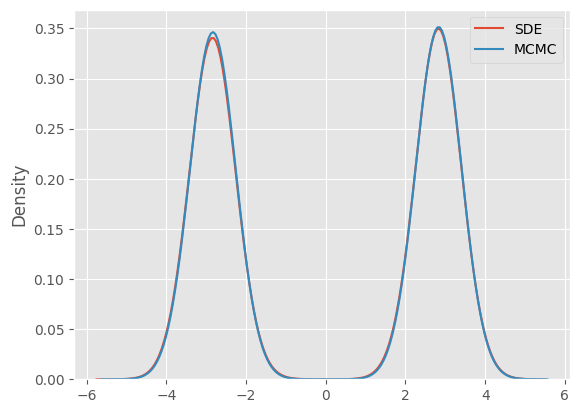

In [28]:
gen_samps = cond_samples[:, 1]
kdeplot(gen_samps, label="SDE")
kdeplot(rej_samps[0, :], label="MCMC")
plt.legend()

In [27]:
wd(np.asarray(gen_samps), rej_samps[0, :])

np.float64(0.01622579387528402)